# Lab 1: Statistical Foundations & Classical Models (Student Version)

## Objective
Apply concepts from Lecture 1 to the Comprehensive BTC/USD 1M Dataset:
1. Data Preprocessing & Resampling.
2. Time Series Decomposition.
3. Testing for Stationarity (ADF Test).
4. Interpreting ACF and PACF plots.
5. Building and evaluating an ARIMA model.

### Task 1: Import Necessary Libraries
Import the standard data science and time-series libraries you will need.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TODO 1: Import the following from statsmodels:
# - seasonal_decompose
# - adfuller (for ADF test)
# - plot_acf, plot_pacf
# - ARIMA

# Your imports here:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

### Task 2: Load the Dataset
We are using the `imranbukhari/comprehensive-btcusd-1m-data` dataset from Kaggle. Run the cell below to download it (if you haven't already).
- We interested in ***Closed***  Price ONLY

In [2]:
# Uncomment and run this if you are using kagglehub to download the dataset directly.
import kagglehub
path = kagglehub.dataset_download("imranbukhari/comprehensive-btcusd-1m-data", output_dir="dataset/")
print("Path to dataset files:", path)

d:\anaconda\envs\iti\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 0.98G/0.98G [05:31<00:00, 3.18MB/s]

Extracting files...


Path to dataset files: dataset/


In [5]:
# TODO 2: Load the dataset using pandas.
# Replace 'YOUR_FILE_NAME.csv' with the actual file name found in your dataset path.
import pandas as pd
df = pd.read_csv("dataset/BTCUSD_1m_Coinbase.csv")

# Print the first 5 rows to inspect the columns.
df.head()

,Open time,Low,High,Open,Close,Volume
0,2015-07-20 21:37:00,277.97,277.98,277.98,277.97,0.791300
1,2015-07-20 21:38:00,277.98,277.99,277.98,277.99,0.560600
2,2015-07-20 21:39:00,277.97,277.97,277.97,277.97,0.149600
3,2015-07-20 21:40:00,277.98,277.99,277.98,277.99,1.216800
4,2015-07-20 21:41:00,277.99,277.99,277.99,277.99,2.704924


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5317710 entries, 0 to 5317709
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Open time  object 
 1   Low        float64
 2   High       float64
 3   Open       float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(5), object(1)
memory usage: 243.4+ MB


### Task 3: Data Preprocessing & Resampling
The dataset contains 1-minute frequency data, which is too granular and noisy for standard ARIMA models. We need to aggregate this into daily data.

In [7]:
# TODO 3.1: Convert the time/date column to pandas datetime objects.
df["Open time"] = pd.to_datetime(df["Open time"])
# TODO 3.2: Set the datetime column as the index of the dataframe.
df.set_index("Open time", inplace=True)
# TODO 3.3: Resample the dataframe to a Daily frequency ('D'). 
btc_daily = df.resample('D').mean()

# TODO 3.4: Drop any missing values (NaNs) that might have resulted from resampling.
btc_daily.dropna(inplace=True)


In [14]:
btc_daily.head()

,Low,High,Open,Close,Volume
Open time,,,,,
2015-07-20,278.324855,278.418986,278.363333,278.383333,5.673068
2015-07-21,279.655995,279.721784,279.690115,279.689740,3.785268
2015-07-22,276.946185,277.010621,276.979267,276.977779,3.506290
2015-07-23,277.600180,277.666820,277.633230,277.631572,3.826186
2015-07-24,283.530254,283.602250,283.561951,283.570710,5.502593


In [8]:
btc_daily.isna().sum()

Low       0
High      0
Open      0
Close     0
Volume    0
dtype: int64

### Task 4: Visualize the Time Series
Let's visualize the daily closing price of BTC.

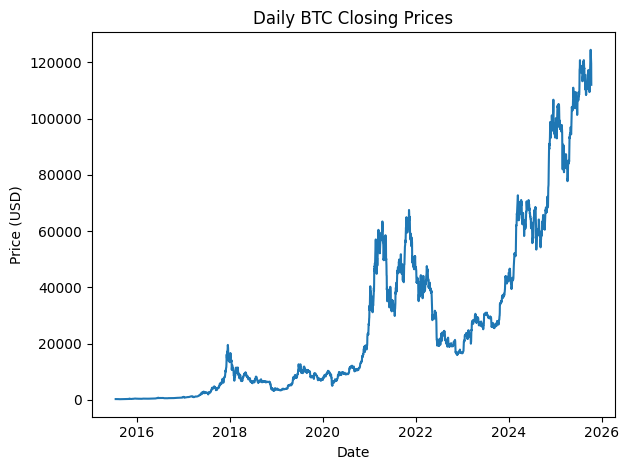

In [11]:
# TODO 4: Plot the daily BTC closing prices.
# Ensure your plot has a title, x-axis label, and y-axis label.
plt.plot(btc_daily.index, btc_daily['Close'])
plt.title('Daily BTC Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

### Task 5: Time Series Decomposition
Decompose the time series to observe its underlying components: Trend, Seasonality, and Residuals.

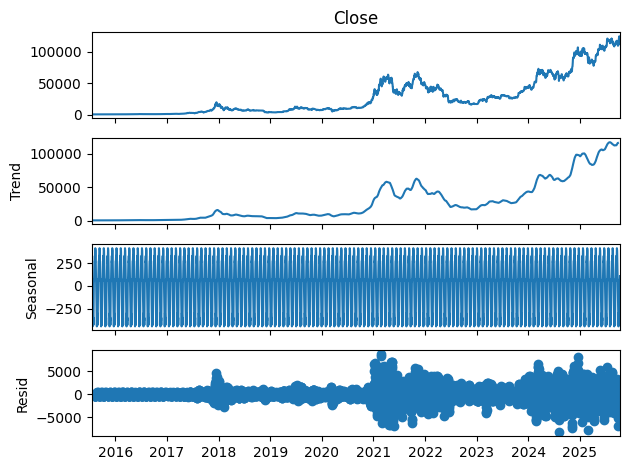

In [12]:
# TODO 5: Use `seasonal_decompose` on the daily closing prices.
# Set the period appropriately (e.g., period=30 for monthly seasonality on daily data, or period=365 for yearly).
decomposition = seasonal_decompose(btc_daily['Close'], model='additive', period=30)

# Plot the decomposition.
decomposition.plot()
plt.show()


### Task 6: Testing for Stationarity (ADF Test)
Before fitting an ARIMA model, we must check if our time series is stationary.

In [13]:
# TODO 6.1: Create a function or write code to perform the Augmented Dickey-Fuller (ADF) test.
# It should print the ADF Statistic and the p-value.
def adf_test(series):
    """ADF Reject Nulls When
    - Statistic < Critical Value(5%)
    - P-value < 0.05
    """
    result = adfuller(series, autolag='BIC')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f"Critical Values:")
    for k, v in  result[4].items():
        print(f"{k}: {v:.4f}")
    if result[1] < 0.05 and result[0] < result[4]['5%']:
        print("Result: Data is STATIONARY (Reject H0)")
    else:
        print("Result: Data is NON-STATIONARY (Fail to reject H0)")

# TODO 6.2: Run the ADF test on your `btc_daily` series.
# Question: Based on the p-value, is the series stationary? (Add your answer as a comment).
adf_test(btc_daily['Close'])


ADF Statistic: 0.3519
p-value: 0.9796
Critical Values:
1%: -3.4321
5%: -2.8623
10%: -2.5672
Result: Data is NON-STATIONARY (Fail to reject H0)


### Task 7: Making the Series Stationary (Differencing)
If the series is not stationary, we need to apply differencing.

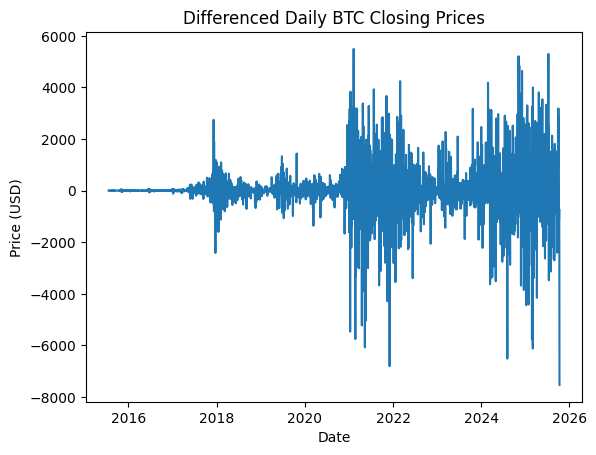

ADF Statistic: -48.4451
p-value: 0.0000
Critical Values:
1%: -3.4321
5%: -2.8623
10%: -2.5672
Result: Data is STATIONARY (Reject H0)


In [15]:
# TODO 7.1: Apply first-order differencing (or log differencing) to the daily closing prices.
btc_stationary = btc_daily["Close"].diff()

# Remember to drop the NaN value created by differencing.
btc_stationary.dropna(inplace=True)

# TODO 7.2: Plot the differenced series.
plt.plot(btc_stationary.index, btc_stationary)
plt.title('Differenced Daily BTC Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

# TODO 7.3: Run the ADF test again on the differenced series to confirm it is now stationary.
adf_test(btc_stationary)

### Task 8: ACF and PACF Plots
Plot the Autocorrelation and Partial Autocorrelation functions to help determine the `p` (AR) and `q` (MA) parameters for the ARIMA model.

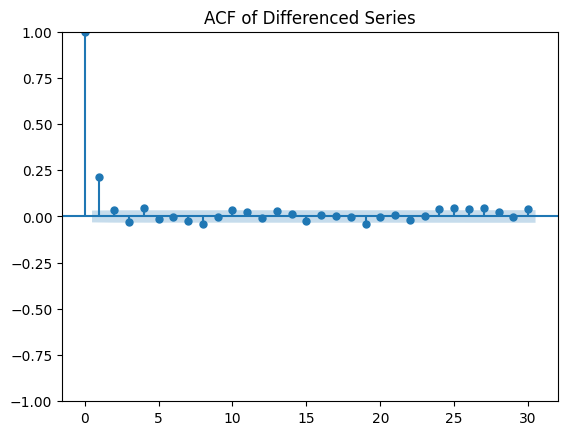

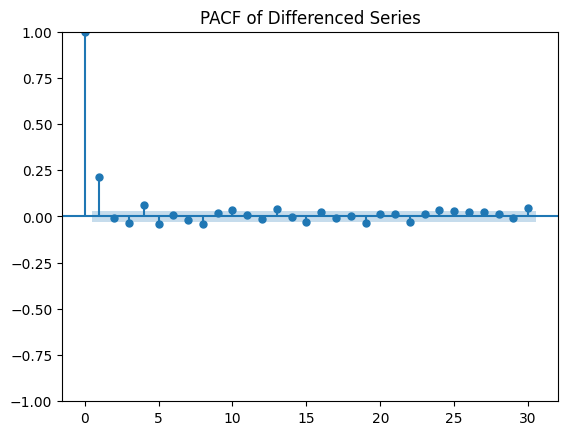

In [16]:
# TODO 8: Plot the ACF and PACF of the STATIONARY (differenced) series.
plot_acf(btc_stationary, lags=30)
plt.title('ACF of Differenced Series')
plt.show()
plot_pacf(btc_stationary, lags=30)
plt.title('PACF of Differenced Series')
plt.show()

### Task 9: Building the ARIMA Model
Split the data into training and testing sets, then build the ARIMA model.

In [17]:
# TODO 9.1: Split the original `btc_daily` data into Train and Test sets.
# E.g., Use the last 60 days as the Test set, and everything before as Train.
train = btc_daily[:-60]
test = btc_daily[-60:]

# TODO 9.2: Initialize and fit an ARIMA model on the training data.
# Pass in the (p, d, q) order based on your previous findings. 
# Note: If you pass the original non-stationary `train` data, set `d=1`. 
model = ARIMA(train['Close'], order=(1, 1, 1)) 
fitted_model = model.fit()

# Print the model summary.
print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 3677
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -30021.568
Date:                Fri, 06 Mar 2026   AIC                          60049.137
Time:                        13:48:05   BIC                          60067.765
Sample:                    07-20-2015   HQIC                         60055.768
                         - 08-12-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1766      0.047      3.725      0.000       0.084       0.270
ma.L1          0.0312      0.048      0.645      0.519      -0.064       0.126
sigma2      7.273e+05   6760.331    107.577      0.0

### Task 10: Evaluation & Forecasting
Forecast the test period and visualize how well your model performed against the actual unseen test data.

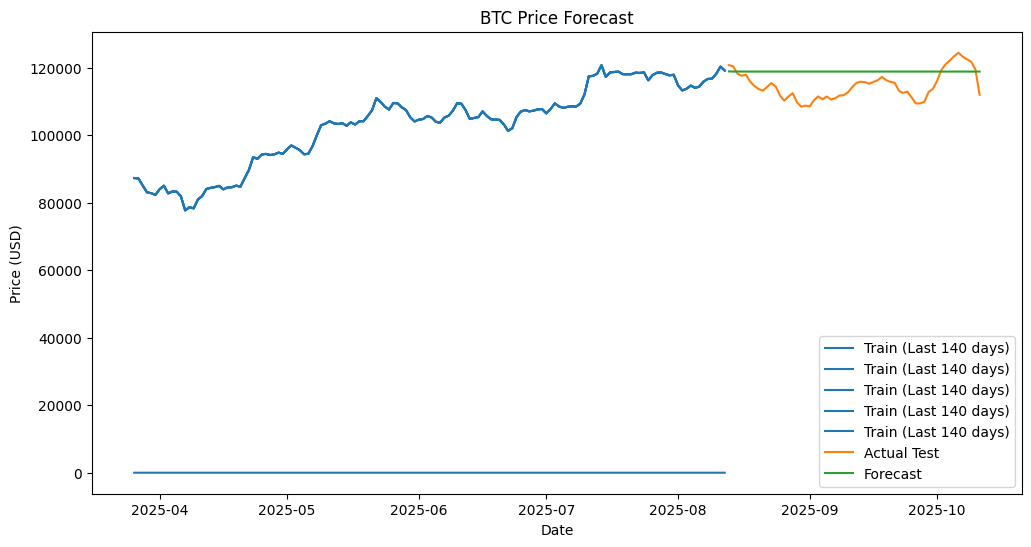

In [18]:
# TODO 10.1: Generate forecasts for the length of the test set.
forecast = fitted_model.forecast(steps=len(test))

# TODO 10.2: Plot the Training data, Actual Test data, and the Forecasted values on the same plot.
# You may want to zoom in on the last part of the timeline (e.g., last 200 days) to see the forecast clearly.
plt.figure(figsize=(12, 6))
plt.plot(train.index[-140:], train[-140:], label='Train (Last 140 days)', color='tab:blue')
plt.plot(test.index, test['Close'], label='Actual Test', color='tab:orange')
plt.plot(test.index, forecast, label='Forecast', color='tab:green')
plt.title('BTC Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()
